In [1]:
!pip install geopandas pyogrio shapely fiona rtree tqdm -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [42]:
import os
import zipfile
import requests
import geopandas as gpd
import pandas as pd

project_path = "/content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua"
data_path = f"{project_path}/data"
output_path = f"{project_path}/output"

os.makedirs(data_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

geofabrik_shp_files = {
    "sulawesi": "https://download.geofabrik.de/asia/indonesia/sulawesi-latest-free.shp.zip",
    "maluku": "https://download.geofabrik.de/asia/indonesia/maluku-latest-free.shp.zip",
    "papua": "https://download.geofabrik.de/asia/indonesia/papua-latest-free.shp.zip"
}

for region, url in geofabrik_shp_files.items():
    zip_path = f"{data_path}/{region}-latest-free.shp.zip"

    if not os.path.exists(zip_path):
        print(f"Downloading {region}...")
        r = requests.get(url, stream=True)
        r.raise_for_status()

        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    else:
        print(f"{region} already exists.")

In [43]:
for region in geofabrik_shp_files.keys():
    zip_path = f"{data_path}/{region}-latest-free.shp.zip"
    extract_dir = f"{data_path}/{region}_shp"
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    print(region, "extracted to", extract_dir)

sulawesi extracted to /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/sulawesi_shp
maluku extracted to /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/maluku_shp
papua extracted to /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/papua_shp


In [44]:
def find_roads_shp(folder):
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file == "gis_osm_roads_free_1.shp":
                return os.path.join(root, file)
    return None

road_shp_paths = {}

for region in geofabrik_shp_files.keys():
    folder = f"{data_path}/{region}_shp"
    road_shp_paths[region] = find_roads_shp(folder)
    print(region, ":", road_shp_paths[region])

sulawesi : /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/sulawesi_shp/gis_osm_roads_free_1.shp
maluku : /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/maluku_shp/gis_osm_roads_free_1.shp
papua : /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/data/papua_shp/gis_osm_roads_free_1.shp


In [45]:
roads_list = []

for region, shp_path in road_shp_paths.items():
    if shp_path is None:
        print(f"File jalan tidak ditemukan untuk {region}")
        continue

    print("Reading:", region)
    temp = gpd.read_file(shp_path)
    temp["region_source"] = region
    roads_list.append(temp)

if len(roads_list) == 0:
    raise ValueError("Tidak ada file jalan yang berhasil dibaca.")

roads = pd.concat(roads_list, ignore_index=True)
roads = gpd.GeoDataFrame(roads, geometry="geometry", crs=roads_list[0].crs)

print("Total roads:", roads.shape)
print("CRS:", roads.crs)
roads.head()

Reading: sulawesi
Reading: maluku
Reading: papua
Total roads: (502103, 12)
CRS: EPSG:4326


,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry,region_source
0,25865607,5153,footway,None,None,B,0,0,F,F,"LINESTRING (121.76087 -5.34271, 121.76089 -5.3...",sulawesi
1,28887503,5115,tertiary,Jalan Dotulolong Lasut,None,F,0,0,F,F,"LINESTRING (124.84161 1.49415, 124.84155 1.493...",sulawesi
2,28887506,5141,service,Jalan Laksda John Lie,None,F,0,0,F,F,"LINESTRING (124.83652 1.48663, 124.83641 1.486...",sulawesi
3,28887507,5141,service,None,None,F,0,0,F,F,"LINESTRING (124.83402 1.48491, 124.83414 1.484...",sulawesi
4,28887510,5115,tertiary,Jalan W.R. Supratman,None,B,0,0,F,F,"LINESTRING (124.84163 1.48733, 124.84189 1.487...",sulawesi


In [46]:
roads["fclass"].value_counts().head(30)

,count
fclass,
residential,296857
service,47542
track,46006
path,31930
unclassified,31789
trunk,12475
tertiary,9130
living_street,9020
footway,7649


In [47]:
boundary_file = f"{data_path}/batas_kabkot_sulampua.geojson"

kabkot = gpd.read_file(boundary_file)
kabkot = kabkot.to_crs(4326)

print(kabkot.shape)
print(kabkot.columns)
print(kabkot.total_bounds)
kabkot.head()

(134, 14)
Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry'],
      dtype='object')
[117.0389  -9.1182 141.0194   5.5657]


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IDN.6.1_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Boalemo,NA,NA,Kabupaten,Regency,7501,ID.GO.BO,"MULTIPOLYGON (((122.6306 0.4871, 122.6248 0.48..."
1,IDN.6.2_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,BoneBolango,NA,NA,Kabupaten,Regency,7504,ID.GO.BB,"MULTIPOLYGON (((123.4632 0.3317, 123.4637 0.33..."
2,IDN.6.3_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,DanauLimboto,NA,NA,Kabupaten,Regency,7502,ID.GO.GO,"MULTIPOLYGON (((122.9845 0.5558, 122.982 0.558..."
3,IDN.6.5_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Gorontalo,NA,NA,Kabupaten,Regency,7502,ID.GO.GO,"MULTIPOLYGON (((122.9869 0.5547, 122.9966 0.55..."
4,IDN.6.4_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,GorontaloUtara,NA,NA,Kabupaten,Regency,7505,ID.GO.GU,"MULTIPOLYGON (((122.8156 0.8488, 122.8174 0.84..."


In [48]:
kabkot = kabkot.rename(columns={
    "NAME_1": "provinsi",
    "NAME_2": "kabupaten_kota"
})

In [49]:
print(kabkot["provinsi"].unique())
print(kabkot.shape)

['Gorontalo' 'Maluku' 'MalukuUtara' 'Papua' 'PapuaBarat' 'SulawesiBarat'
 'SulawesiSelatan' 'SulawesiTengah' 'SulawesiTenggara' 'SulawesiUtara']
(134, 14)


In [50]:
valid_road_classes = [
    "motorway",
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "unclassified",
    "residential",
    "service",
    "living_street",
    "motorway_link",
    "trunk_link",
    "primary_link",
    "secondary_link",
    "tertiary_link"
]

roads_filtered = roads[roads["fclass"].isin(valid_road_classes)].copy()

print("Before filter:", roads.shape)
print("After filter:", roads_filtered.shape)

if len(roads_filtered) == 0:
    raise ValueError("Filter fclass menghasilkan 0 jalan. Cek roads['fclass'].value_counts().")

Before filter: (502103, 12)
After filter: (415394, 12)


In [51]:
roads_filtered = roads_filtered.to_crs(4326)
kabkot = kabkot.to_crs(4326)

print("kabkot bounds:", kabkot.total_bounds)
print("roads bounds:", roads_filtered.total_bounds)

minx, miny, maxx, maxy = kabkot.total_bounds

roads_bbox = roads_filtered.cx[minx:maxx, miny:maxy].copy()

print("Jalan masuk bounding box kabkot:", roads_bbox.shape)

kabkot bounds: [117.0389  -9.1182 141.0194   5.5657]
roads bounds: [117.0692638  -8.8373841 141.1343601   5.5656587]
Jalan masuk bounding box kabkot: (415394, 12)


In [52]:
kabkot_m = kabkot.to_crs(6933).copy()
kabkot["luas_km2"] = kabkot_m.geometry.area / 1_000_000

In [53]:
kabkot_overlay = kabkot[["provinsi", "kabupaten_kota", "luas_km2", "geometry"]].copy()
roads_overlay = roads_bbox[["fclass", "geometry"]].copy()

kabkot_overlay["geometry"] = kabkot_overlay.geometry.make_valid()
roads_overlay["geometry"] = roads_overlay.geometry.make_valid()

kabkot_overlay = kabkot_overlay[
    kabkot_overlay.geometry.notna() & ~kabkot_overlay.geometry.is_empty
].copy()

roads_overlay = roads_overlay[
    roads_overlay.geometry.notna() & ~roads_overlay.geometry.is_empty
].copy()

roads_intersect = gpd.overlay(
    roads_overlay,
    kabkot_overlay,
    how="intersection",
    keep_geom_type=True
)

print("Hasil intersection:", roads_intersect.shape)
roads_intersect.head()

Hasil intersection: (413062, 5)


,fclass,provinsi,kabupaten_kota,luas_km2,geometry
0,tertiary,SulawesiUtara,Manado,163.058577,"LINESTRING (124.84161 1.49415, 124.84155 1.493..."
1,service,SulawesiUtara,Manado,163.058577,"LINESTRING (124.83652 1.48663, 124.83641 1.486..."
2,service,SulawesiUtara,Manado,163.058577,"LINESTRING (124.83402 1.48491, 124.83414 1.484..."
3,tertiary,SulawesiUtara,Manado,163.058577,"LINESTRING (124.84163 1.48733, 124.84189 1.487..."
4,tertiary,SulawesiUtara,Manado,163.058577,"LINESTRING (124.84261 1.4795, 124.84213 1.4795..."


<Axes: >

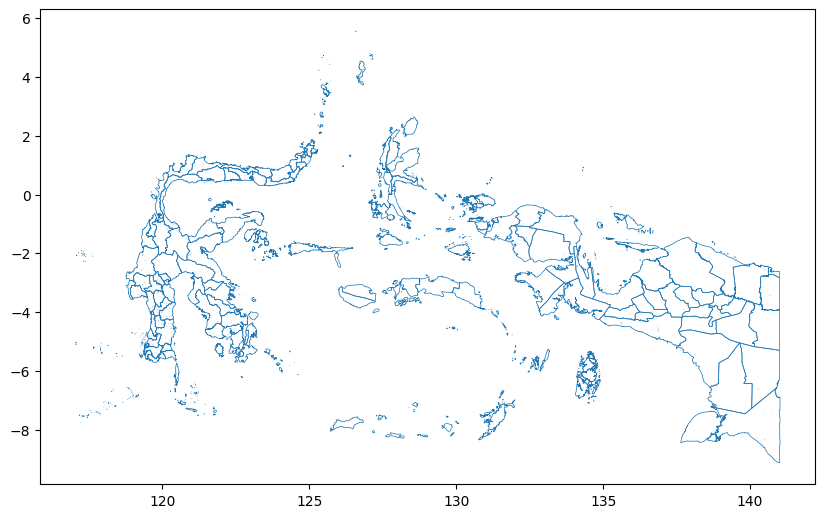

In [54]:
ax = kabkot.boundary.plot(figsize=(10, 10), linewidth=0.5)
roads_bbox.sample(min(5000, len(roads_bbox))).plot(ax=ax, linewidth=0.2)

In [55]:
roads_intersect_m = roads_intersect.to_crs(6933).copy()

roads_intersect_m["road_length_km"] = roads_intersect_m.geometry.length / 1000

road_length_kabkot = (
    roads_intersect_m
    .groupby(["provinsi", "kabupaten_kota"], as_index=False)
    ["road_length_km"]
    .sum()
)

road_length_kabkot.sort_values("road_length_km", ascending=False).head(20)

,provinsi,kabupaten_kota,road_length_km
74,SulawesiSelatan,Bone,4345.700923
77,SulawesiSelatan,Gowa,3545.689764
42,Papua,Merauke,3392.032067
69,SulawesiBarat,Mamuju,3167.040119
83,SulawesiSelatan,Makassar,3049.814592
96,SulawesiTengah,Banggai,3003.844467
115,SulawesiTenggara,KonaweSelatan,2858.563201
100,SulawesiTengah,Morowali,2796.869184
112,SulawesiTenggara,Kolaka,2659.589129
59,PapuaBarat,Manokwari,2594.106080


In [56]:
road_density = kabkot.merge(
    road_length_kabkot,
    on=["provinsi", "kabupaten_kota"],
    how="left"
)

road_density["road_length_km"] = road_density["road_length_km"].fillna(0)

road_density["road_density_km_per_km2"] = (
    road_density["road_length_km"] / road_density["luas_km2"]
)

road_density["road_density_km_per_100km2"] = (
    road_density["road_density_km_per_km2"] * 100
)

road_density[[
    "provinsi",
    "kabupaten_kota",
    "luas_km2",
    "road_length_km",
    "road_density_km_per_km2",
    "road_density_km_per_100km2"
]].sort_values("road_length_km", ascending=False).head(30)

,provinsi,kabupaten_kota,luas_km2,road_length_km,road_density_km_per_km2,road_density_km_per_100km2
74,SulawesiSelatan,Bone,4602.629643,4345.700923,0.944178,94.417784
77,SulawesiSelatan,Gowa,1805.176702,3545.689764,1.964179,196.417878
42,Papua,Merauke,43773.480858,3392.032067,0.077491,7.749057
69,SulawesiBarat,Mamuju,7665.316901,3167.040119,0.413165,41.316493
83,SulawesiSelatan,Makassar,182.164567,3049.814592,16.742085,1674.208464
96,SulawesiTengah,Banggai,8367.432825,3003.844467,0.358992,35.899236
115,SulawesiTenggara,KonaweSelatan,4251.896088,2858.563201,0.672303,67.230317
100,SulawesiTengah,Morowali,13089.026070,2796.869184,0.213680,21.368047
112,SulawesiTenggara,Kolaka,6732.130949,2659.589129,0.395059,39.505903
59,PapuaBarat,Manokwari,12879.895613,2594.106080,0.201407,20.140738


In [57]:
csv_output = f"{output_path}/road_density_sulampua.csv"
geojson_output = f"{output_path}/road_density_sulampua.geojson"

road_density.drop(columns="geometry").to_csv(csv_output, index=False)
road_density.to_file(geojson_output, driver="GeoJSON")

print("CSV saved to:", csv_output)
print("GeoJSON saved to:", geojson_output)

CSV saved to: /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/road_density_sulampua.csv
GeoJSON saved to: /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/road_density_sulampua.geojson


In [58]:
!pip install networkx tqdm -q

In [59]:
import geopandas as gpd
import pandas as pd
import numpy as np
import networkx as nx
from shapely.geometry import LineString, MultiLineString
from tqdm import tqdm

In [60]:
kabkot
roads_filtered

,osm_id,code,fclass,name,ref,oneway,maxspeed,layer,bridge,tunnel,geometry,region_source
1,28887503,5115,tertiary,Jalan Dotulolong Lasut,None,F,0,0,F,F,"LINESTRING (124.84161 1.49415, 124.84155 1.493...",sulawesi
2,28887506,5141,service,Jalan Laksda John Lie,None,F,0,0,F,F,"LINESTRING (124.83652 1.48663, 124.83641 1.486...",sulawesi
3,28887507,5141,service,None,None,F,0,0,F,F,"LINESTRING (124.83402 1.48491, 124.83414 1.484...",sulawesi
4,28887510,5115,tertiary,Jalan W.R. Supratman,None,B,0,0,F,F,"LINESTRING (124.84163 1.48733, 124.84189 1.487...",sulawesi
5,28887511,5115,tertiary,None,None,F,0,0,F,F,"LINESTRING (124.84261 1.4795, 124.84213 1.4795...",sulawesi
...,...,...,...,...,...,...,...,...,...,...,...,...
502085,1518991484,5122,residential,Gg.Leli 2,None,B,20,0,F,F,"LINESTRING (140.6386 -2.59679, 140.63836 -2.59...",papua
502086,1518991584,5122,residential,Gg.Anggrek III,None,B,20,0,F,F,"LINESTRING (140.63885 -2.59658, 140.63899 -2.5...",papua
502100,1521099648,5141,service,None,None,B,0,0,F,F,"LINESTRING (136.87372 -4.40443, 136.87199 -4.3...",papua
502101,1521099649,5122,residential,None,None,B,0,0,F,F,"LINESTRING (136.86095 -4.39437, 136.86069 -4.3...",papua


In [61]:
print("kabkot:", kabkot.shape)
print("roads_filtered:", roads_filtered.shape)

print("kabkot CRS:", kabkot.crs)
print("roads_filtered CRS:", roads_filtered.crs)

kabkot: (134, 15)
roads_filtered: (415394, 12)
kabkot CRS: EPSG:4326
roads_filtered CRS: EPSG:4326


In [62]:
kabkot = kabkot.to_crs(4326).copy()
roads_filtered = roads_filtered.to_crs(4326).copy()

In [63]:
def extract_lines(geom):
    """
    Mengambil LineString dari LineString atau MultiLineString.
    """
    if geom is None or geom.is_empty:
        return []

    if isinstance(geom, LineString):
        return [geom]

    if isinstance(geom, MultiLineString):
        return list(geom.geoms)

    return []


def round_node(coord, precision=5):
    """
    Membulatkan koordinat agar node yang sangat dekat dianggap sama.
    precision=5 kira-kira sekitar 1 meter pada koordinat derajat.
    """
    return (round(coord[0], precision), round(coord[1], precision))


def build_road_graph(gdf, precision=5):
    """
    Membentuk graph NetworkX dari GeoDataFrame jalan.
    """
    G = nx.Graph()

    for geom in gdf.geometry:
        lines = extract_lines(geom)

        for line in lines:
            coords = list(line.coords)

            if len(coords) < 2:
                continue

            start = round_node(coords[0], precision)
            end = round_node(coords[-1], precision)

            if start == end:
                continue

            length = line.length

            G.add_edge(start, end, length=length)

    return G

In [64]:
def calculate_connectivity_metrics(G):
    """
    Menghitung indeks konektivitas jaringan jalan.
    """
    nodes = G.number_of_nodes()
    edges = G.number_of_edges()

    if nodes == 0 or edges == 0:
        return {
            "nodes": nodes,
            "edges": edges,
            "components": 0,
            "largest_component_edges": 0,
            "largest_component_ratio": 0,
            "beta_index": 0,
            "gamma_index": 0,
            "alpha_index": 0
        }

    components = nx.number_connected_components(G)

    component_edges = []
    for component_nodes in nx.connected_components(G):
        subgraph = G.subgraph(component_nodes)
        component_edges.append(subgraph.number_of_edges())

    largest_component_edges = max(component_edges) if component_edges else 0
    largest_component_ratio = largest_component_edges / edges if edges > 0 else 0

    beta_index = edges / nodes if nodes > 0 else 0

    if nodes > 2:
        gamma_index = edges / (3 * (nodes - 2))
    else:
        gamma_index = 0

    if nodes > 2:
        alpha_index = (edges - nodes + components) / (2 * nodes - 5)
    else:
        alpha_index = 0

    alpha_index = max(alpha_index, 0)
    gamma_index = max(gamma_index, 0)

    return {
        "nodes": nodes,
        "edges": edges,
        "components": components,
        "largest_component_edges": largest_component_edges,
        "largest_component_ratio": largest_component_ratio,
        "beta_index": beta_index,
        "gamma_index": gamma_index,
        "alpha_index": alpha_index
    }

In [65]:
# Pastikan kolom tersedia
required_cols = ["provinsi", "kabupaten_kota", "geometry"]

missing_cols = [col for col in required_cols if col not in kabkot.columns]
if missing_cols:
    raise ValueError(f"Kolom ini belum ada di kabkot: {missing_cols}")

# Perbaiki geometri
kabkot_conn = kabkot[["provinsi", "kabupaten_kota", "geometry"]].copy()
roads_conn = roads_filtered[["geometry"]].copy()

kabkot_conn = kabkot_conn.to_crs(4326)
roads_conn = roads_conn.to_crs(4326)

kabkot_conn["geometry"] = kabkot_conn.geometry.make_valid()
roads_conn["geometry"] = roads_conn.geometry.make_valid()

kabkot_conn = kabkot_conn[
    kabkot_conn.geometry.notna() & ~kabkot_conn.geometry.is_empty
].copy()

roads_conn = roads_conn[
    roads_conn.geometry.notna() & ~roads_conn.geometry.is_empty
].copy()

In [67]:

connectivity_results = []

for idx, row in tqdm(kabkot_conn.iterrows(), total=len(kabkot_conn)):
    provinsi = row["provinsi"]
    kabupaten_kota = row["kabupaten_kota"]
    geom = row.geometry

    # Ambil jalan yang masuk bounding box kabupaten/kota
    minx, miny, maxx, maxy = geom.bounds
    roads_candidate = roads_conn.cx[minx:maxx, miny:maxy].copy()

    if len(roads_candidate) == 0:
        metrics = calculate_connectivity_metrics(nx.Graph())
    else:
        # Potong jalan sesuai wilayah kabupaten/kota
        clipped = gpd.clip(roads_candidate, gpd.GeoDataFrame(geometry=[geom], crs=kabkot_conn.crs))

        if len(clipped) == 0:
            metrics = calculate_connectivity_metrics(nx.Graph())
        else:
            # Ubah ke CRS meter agar panjang lebih stabil kalau nanti dipakai
            clipped = clipped.to_crs(6933)

            G = build_road_graph(clipped, precision=1)
            metrics = calculate_connectivity_metrics(G)

    metrics["provinsi"] = provinsi
    metrics["kabupaten_kota"] = kabupaten_kota

    connectivity_results.append(metrics)

connectivity_df = pd.DataFrame(connectivity_results)

connectivity_df.head()

100%|██████████| 134/134 [00:50<00:00,  2.66it/s]


,nodes,edges,components,largest_component_edges,largest_component_ratio,beta_index,gamma_index,alpha_index,provinsi,kabupaten_kota
0,2520,1666,866,133,0.079832,0.661111,0.220545,0.002383,Gorontalo,Boalemo
1,5132,3217,1919,235,0.073049,0.626851,0.209032,0.000390,Gorontalo,BoneBolango
2,74,44,30,4,0.090909,0.594595,0.203704,0.000000,Gorontalo,DanauLimboto
3,11389,7111,4304,165,0.023203,0.624374,0.208161,0.001142,Gorontalo,Gorontalo
4,1849,1172,682,152,0.129693,0.633856,0.211514,0.001354,Gorontalo,GorontaloUtara


In [68]:
def minmax_norm(series):
    min_val = series.min()
    max_val = series.max()

    if max_val == min_val:
        return series * 0

    return (series - min_val) / (max_val - min_val)


connectivity_df["beta_norm"] = minmax_norm(connectivity_df["beta_index"])
connectivity_df["gamma_norm"] = minmax_norm(connectivity_df["gamma_index"])
connectivity_df["alpha_norm"] = minmax_norm(connectivity_df["alpha_index"])
connectivity_df["lcr_norm"] = connectivity_df["largest_component_ratio"]

connectivity_df["connectivity_index"] = (
    0.35 * connectivity_df["beta_norm"] +
    0.30 * connectivity_df["gamma_norm"] +
    0.20 * connectivity_df["alpha_norm"] +
    0.15 * connectivity_df["lcr_norm"]
)

connectivity_df[[
    "provinsi",
    "kabupaten_kota",
    "nodes",
    "edges",
    "components",
    "beta_index",
    "gamma_index",
    "alpha_index",
    "largest_component_ratio",
    "connectivity_index"
]].sort_values("connectivity_index", ascending=False).head(30)

,provinsi,kabupaten_kota,nodes,edges,components,beta_index,gamma_index,alpha_index,largest_component_ratio,connectivity_index
38,Papua,LannyJaya,408,315,97,0.772059,0.258621,0.004932,0.349206,0.828058
45,Papua,Nduga,308,228,83,0.740260,0.248366,0.004910,0.407895,0.739032
55,Papua,Yalimo,307,230,79,0.749186,0.251366,0.003284,0.360870,0.718368
49,Papua,PuncakJaya,400,291,110,0.727500,0.243719,0.001258,0.316151,0.590913
54,Papua,Yahukimo,851,617,234,0.725029,0.242246,0.000000,0.418152,0.563723
13,Maluku,MalukuTenggara,2678,1807,913,0.674757,0.225087,0.007849,0.080243,0.555236
102,SulawesiTengah,ParigiMoutong,6995,4759,2339,0.680343,0.226846,0.007365,0.032780,0.552688
48,Papua,Puncak,288,207,81,0.718750,0.241259,0.000000,0.376812,0.542739
110,SulawesiTenggara,ButonUtara,1412,993,427,0.703258,0.234752,0.002838,0.183283,0.532197
50,Papua,Sarmi,964,684,283,0.709544,0.237006,0.001560,0.216374,0.524796


In [69]:
aeds_road = road_density.merge(
    connectivity_df,
    on=["provinsi", "kabupaten_kota"],
    how="left"
)

aeds_road.head()

,GID_2,GID_0,COUNTRY,GID_1,provinsi,NL_NAME_1,kabupaten_kota,VARNAME_2,NL_NAME_2,TYPE_2,...,largest_component_edges,largest_component_ratio,beta_index,gamma_index,alpha_index,beta_norm,gamma_norm,alpha_norm,lcr_norm,connectivity_index
0,IDN.6.1_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Boalemo,NA,NA,Kabupaten,...,133,0.079832,0.661111,0.220545,0.002383,0.466047,0.459141,0.303646,0.079832,0.373563
1,IDN.6.2_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,BoneBolango,NA,NA,Kabupaten,...,235,0.073049,0.626851,0.209032,0.000390,0.301166,0.295591,0.049675,0.073049,0.214978
2,IDN.6.3_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,DanauLimboto,NA,NA,Kabupaten,...,4,0.090909,0.594595,0.203704,0.000000,0.145926,0.219904,0.000000,0.090909,0.130682
3,IDN.6.5_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,Gorontalo,NA,NA,Kabupaten,...,165,0.023203,0.624374,0.208161,0.001142,0.289246,0.283225,0.145458,0.023203,0.218776
4,IDN.6.4_1,IDN,Indonesia,IDN.6_1,Gorontalo,NA,GorontaloUtara,NA,NA,Kabupaten,...,152,0.129693,0.633856,0.211514,0.001354,0.334878,0.330852,0.172495,0.129693,0.270416


In [70]:
connectivity_csv = f"{output_path}/road_connectivity_index_sulampua.csv"
aeds_road_csv = f"{output_path}/aeds_road_density_connectivity_sulampua.csv"
aeds_road_geojson = f"{output_path}/aeds_road_density_connectivity_sulampua.geojson"

connectivity_df.to_csv(connectivity_csv, index=False)
aeds_road.drop(columns="geometry").to_csv(aeds_road_csv, index=False)
aeds_road.to_file(aeds_road_geojson, driver="GeoJSON")

print("Connectivity CSV saved:", connectivity_csv)
print("AEDS road CSV saved:", aeds_road_csv)
print("AEDS road GeoJSON saved:", aeds_road_geojson)

Connectivity CSV saved: /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/road_connectivity_index_sulampua.csv
AEDS road CSV saved: /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/aeds_road_density_connectivity_sulampua.csv
AEDS road GeoJSON saved: /content/drive/MyDrive/Karya Ilmiah/AEDS_Sulampua/output/aeds_road_density_connectivity_sulampua.geojson
